# Bias and Variance

This notebook uses mathematical calculations and simulations to study estimator bias, variance, MSE, standard error, and the bias–variance trade-off.


## 1. Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 2. Bias of an Estimator

Suppose the true parameter is $10$ and an estimator has expected value $12.5$.


In [2]:
theta = 10
expected_estimate = 12.5
bias = expected_estimate - theta

print("Bias:", bias)


Bias: 2.5


## 3. MSE Decomposition

Verify:

$$
MSE=Bias^2+Variance
$$

for bias $=2$ and variance $=9$.


In [3]:
bias = 2
variance = 9

mse_from_components = bias**2 + variance
print("MSE:", mse_from_components)
print("RMSE:", np.sqrt(mse_from_components))


MSE: 13
RMSE: 3.605551275463989


## 4. Sampling Distribution of the Sample Mean

Suppose:

$$
\mu=50,\qquad \sigma=10,\qquad n=30
$$


In [4]:
rng = np.random.default_rng(42)

mu = 50
sigma = 10
n = 30
repetitions = 5000

sample_means = np.array([
    rng.normal(mu, sigma, n).mean()
    for _ in range(repetitions)
])

print("Mean of sample means:", sample_means.mean())
print("Empirical variance:", sample_means.var())
print("Theoretical variance:", sigma**2 / n)
print("Theoretical standard error:", sigma / np.sqrt(n))


Mean of sample means: 49.96653261291568
Empirical variance: 3.3665576271194046
Theoretical variance: 3.3333333333333335
Theoretical standard error: 1.8257418583505538


## 5. Visualising Sampling Variability


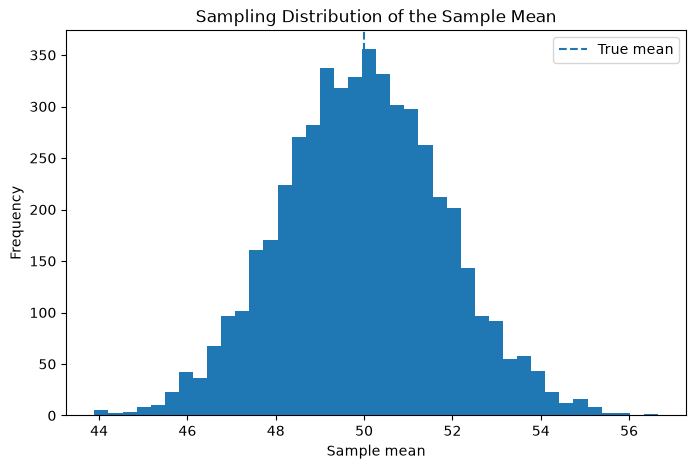

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=40)
plt.axvline(mu, linestyle="--", label="True mean")
plt.xlabel("Sample mean")
plt.ylabel("Frequency")
plt.title("Sampling Distribution of the Sample Mean")
plt.legend()
plt.show()


## 6. A Deliberately Biased Estimator

Define:

$$
\hat{\mu}_{biased}=\bar{X}+2
$$


In [6]:
biased_estimates = sample_means + 2

estimated_bias = biased_estimates.mean() - mu

print("Estimated bias:", estimated_bias)
print("Original variance:", sample_means.var())
print("Biased-estimator variance:", biased_estimates.var())


Estimated bias: 1.9665326129156782
Original variance: 3.3665576271194046
Biased-estimator variance: 3.3665576271194046


## 7. Empirical MSE Decomposition


In [7]:
estimated_bias = biased_estimates.mean() - mu
estimated_variance = biased_estimates.var()
estimated_mse = np.mean((biased_estimates - mu)**2)

print("Bias:", estimated_bias)
print("Variance:", estimated_variance)
print("MSE directly:", estimated_mse)
print("Bias^2 + Variance:", estimated_bias**2 + estimated_variance)


Bias: 1.9665326129156782
Variance: 3.3665576271194046
MSE directly: 7.233808144780371
Bias^2 + Variance: 7.233808144780369


## 8. Effect of Sample Size on Variance


In [8]:
sample_sizes = [10, 25, 50, 100, 250]

for n_value in sample_sizes:
    means = np.array([
        rng.normal(mu, sigma, n_value).mean()
        for _ in range(repetitions)
    ])
    print(
        "n =", n_value,
        "Empirical variance =", round(means.var(), 4),
        "Theoretical variance =", round(sigma**2 / n_value, 4)
    )


n = 10 Empirical variance = 9.9211 Theoretical variance = 10.0
n = 25 Empirical variance = 3.9206 Theoretical variance = 4.0
n = 50 Empirical variance = 1.9395 Theoretical variance = 2.0
n = 100 Empirical variance = 0.9797 Theoretical variance = 1.0
n = 250 Empirical variance = 0.3994 Theoretical variance = 0.4


## 9. Comparing Two Estimators

Estimator A:

$$
Bias=1,\qquad Variance=4
$$

Estimator B:

$$
Bias=0,\qquad Variance=8
$$


In [9]:
bias_A, variance_A = 1, 4
bias_B, variance_B = 0, 8

mse_A = bias_A**2 + variance_A
mse_B = bias_B**2 + variance_B

print("Estimator A MSE:", mse_A)
print("Estimator B MSE:", mse_B)


Estimator A MSE: 5
Estimator B MSE: 8


## 10. Prediction Bias and Variance Simulation

At a fixed input $x_0$, collect predictions from models trained on many different samples. The mean prediction estimates $E[\hat f(x_0)]$, while the spread of predictions illustrates prediction variance.


In [10]:
def fit_and_predict(degree, x_train, y_train, x0):
    coefficients = np.polyfit(x_train, y_train, degree)
    return np.polyval(coefficients, x0)

x0 = 1.5
true_value = x0**2
predictions_by_degree = {}

for degree in [1, 2, 5, 10]:
    predictions = []
    for _ in range(500):
        x_train = rng.uniform(-3, 3, 30)
        y_train = x_train**2 + rng.normal(0, 2, 30)
        predictions.append(fit_and_predict(degree, x_train, y_train, x0))
    predictions_by_degree[degree] = np.array(predictions)

for degree, predictions in predictions_by_degree.items():
    mean_prediction = predictions.mean()
    prediction_bias = mean_prediction - true_value
    prediction_variance = predictions.var()
    print(
        "Degree:", degree,
        "Bias:", round(prediction_bias, 4),
        "Variance:", round(prediction_variance, 4)
    )


Degree: 1 Bias: 0.6377 Variance: 0.9306
Degree: 2 Bias: 0.002 Variance: 0.2445
Degree: 5 Bias: 0.0424 Variance: 0.6785
Degree: 10 Bias: -0.0861 Variance: 3.9503


## 11. Prediction Distribution by Model Complexity


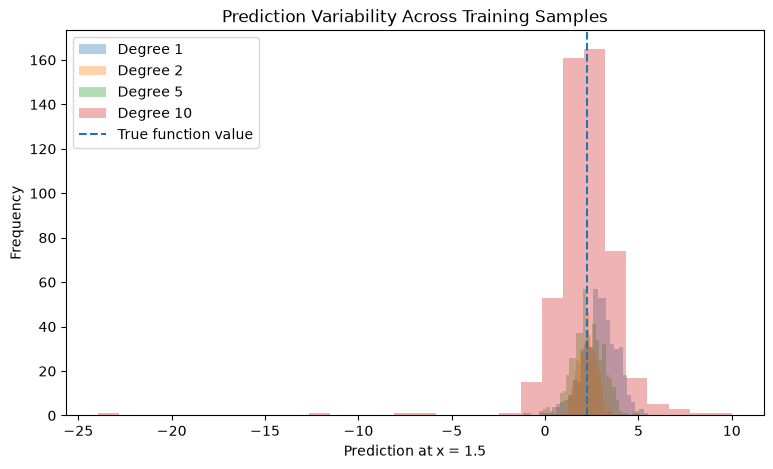

In [11]:
plt.figure(figsize=(9, 5))
for degree, predictions in predictions_by_degree.items():
    plt.hist(predictions, bins=30, alpha=0.35, label=f"Degree {degree}")
plt.axvline(true_value, linestyle="--", label="True function value")
plt.xlabel("Prediction at x = 1.5")
plt.ylabel("Frequency")
plt.title("Prediction Variability Across Training Samples")
plt.legend()
plt.show()


## 12. Training and Test Error


In [12]:
x_train = rng.uniform(-3, 3, 30)
y_train = x_train**2 + rng.normal(0, 2, 30)
x_test = rng.uniform(-3, 3, 200)
y_test = x_test**2 + rng.normal(0, 2, 200)

degrees = range(1, 16)
train_errors = []
test_errors = []

for degree in degrees:
    coefficients = np.polyfit(x_train, y_train, degree)
    train_prediction = np.polyval(coefficients, x_train)
    test_prediction = np.polyval(coefficients, x_test)
    train_errors.append(np.mean((y_train - train_prediction)**2))
    test_errors.append(np.mean((y_test - test_prediction)**2))

print("Minimum test MSE degree:", list(degrees)[int(np.argmin(test_errors))])


Minimum test MSE degree: 2


## 13. Learning Curve Exercise

Repeat the polynomial experiment with different training-set sizes and compare training and test error. The objective is to observe how additional data can affect variance and generalisation.


In [13]:
sample_sizes = [10, 20, 40, 80, 160]
degree = 10

for size in sample_sizes:
    x_train = rng.uniform(-3, 3, size)
    y_train = x_train**2 + rng.normal(0, 2, size)
    coefficients = np.polyfit(x_train, y_train, degree)
    train_prediction = np.polyval(coefficients, x_train)
    test_prediction = np.polyval(coefficients, x_test)
    train_mse = np.mean((y_train - train_prediction)**2)
    test_mse = np.mean((y_test - test_prediction)**2)
    print("n =", size, "Train MSE =", round(train_mse, 3), "Test MSE =", round(test_mse, 3))


n = 10 Train MSE = 0.0 Test MSE = 3325.487
n = 20 Train MSE = 2.847 Test MSE = 275.878
n = 40 Train MSE = 2.72 Test MSE = 6.097
n = 80 Train MSE = 3.358 Test MSE = 5.341
n = 160 Train MSE = 3.52 Test MSE = 4.682


C:\Users\zeesh\AppData\Local\Temp\ipykernel_58508\1764757038.py:7: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_train, y_train, degree)


## 14. Practice Questions

1. If $E[\hat\theta]=25$ and $\theta=20$, calculate bias.
2. If bias is $-3$, explain whether the estimator tends to overestimate or underestimate.
3. If variance is $16$, calculate standard error.
4. If bias is $2$ and variance is $9$, calculate MSE and RMSE.
5. Explain why an unbiased estimator can still have high MSE.
6. For $\sigma=12$ and $n=36$, calculate the variance and standard error of the sample mean.
7. Explain why adding a constant to an estimator changes its bias but not its variance.
8. Simulate an unbiased sample-mean estimator and estimate its empirical bias.
9. Construct a biased estimator by adding a constant and verify its bias experimentally.
10. Compare two estimators using MSE.
11. Train polynomial models of degrees 1, 3, 7, and 12 and compare training and test MSE.
12. Repeat the experiment several times and examine prediction variability at one fixed input.
13. Explain why more data can reduce variance without removing structural bias.
14. Explain the difference between theoretical bias and observed test error.
15. Explain the three terms in the prediction bias–variance decomposition.


## 15. Final Practical Checklist

- Identify the parameter before calculating bias.
- Calculate bias from the expected estimator value.
- Distinguish variance from standard error.
- Use $MSE=Bias^2+Variance$ under squared-error estimation loss.
- In prediction, include the irreducible-noise term.
- Do not equate training error directly with bias.
- Use repeated simulation to study sampling variability.
- Compare training and unseen-data performance when studying model complexity.
- Remember that empirical simulation results vary from run to run unless the random seed is fixed.
